# Required imports for regression and classification

In [1]:
from pathlib import Path
import arff
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate, train_test_split, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)


# 1. Data Loading

In [2]:
ROOT = Path.cwd()

if ROOT.name == 'notebooks':
    DATA_PATH = ROOT.parent / 'credit.arff'
elif ROOT.name == 'statistical-data-analysis':
    DATA_PATH = 'credit.arff'
else:
    DATA_PATH = 'statistical-data-analysis/credit.arff'
    
with open(DATA_PATH, 'r') as f:
    arff_data = arff.load(f)
    
data = arff_data['data']
column_names = [attr[0] for attr in arff_data['attributes']]
    
df = pd.DataFrame(data, columns=column_names)
df.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,10139122,"35,000",3 years,NaN,160000.0,VERIFIED - income,credit_card,14.86,1,NaN,6,26,Male,None
1,10025461,"15,000",10+ years,Rent,41000.0,not verified,debt_consolidation,16.51,0,21.0,13,36,Female,None
2,10154747,"11,000",5 years,Mortgage,59000.0,not verified,debt_consolidation,21.75,0,NaN,11,20,Male,None
3,10032437,"12,000",NaN,Mortgage,72000.0,VERIFIED - income,debt_consolidation,15.73,1,NaN,7,20,Female,None
4,10060564,"20,000",< 1 year,Other,79404.0,VERIFIED - income,debt_consolidation,15.32,3,58.0,18,33,Female,None


In [3]:
df['Loan_Amount_Requested'] = df['Loan_Amount_Requested'].str.replace(',', '').astype(float)

# 2. Regressions

### 2.1 Linear regression

First thing we do is predicting a continous value. We use credit_score dataset, and we try to predict Annual_Income 

In [5]:
X_reg = df.drop([
    'Annual_Income',
    'Loan_ID',
    'Purpose_Of_Loan',
    'Months_Since_Deliquency',
], axis=1).copy()
y_reg = df['Annual_Income'].copy()

display(X_reg.head())
y_reg.describe()

,Loan_Amount_Requested,Length_Employed,Home_Owner,Income_Verified,Debt_To_Income,Inquiries_Last_6Mo,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,35000.0,3 years,NaN,VERIFIED - income,14.86,1,6,26,Male,None
1,15000.0,10+ years,Rent,not verified,16.51,0,13,36,Female,None
2,11000.0,5 years,Mortgage,not verified,21.75,0,11,20,Male,None
3,12000.0,NaN,Mortgage,VERIFIED - income,15.73,1,7,20,Female,None
4,20000.0,< 1 year,Other,VERIFIED - income,15.32,3,18,33,Female,None


count    2.789400e+04
mean     7.261447e+04
std      4.687976e+04
min      7.000000e+03
25%      4.500000e+04
50%      6.200000e+04
75%      8.800000e+04
max      1.950000e+06
Name: Annual_Income, dtype: float64

In [6]:
y_reg = y_reg.fillna(y_reg.mean())

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

numeric_features = X_reg.select_dtypes(include='number').columns.tolist()
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = X_reg.select_dtypes(exclude='number').columns.tolist()
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

reg_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

reg_model = Pipeline([
    ('preprocessor', reg_preprocessor),
    ('regressor', LinearRegression())
])

reg_model.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [8]:
train_pred_reg = reg_model.predict(X_train_reg)
test_pred_reg = reg_model.predict(X_test_reg)

reg_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'MAE': [
        mean_absolute_error(y_train_reg, train_pred_reg),
        mean_absolute_error(y_test_reg, test_pred_reg)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_reg))
    ],
    'R2': [
        r2_score(y_train_reg, train_pred_reg),
        r2_score(y_test_reg, test_pred_reg)
    ]
})

reg_metrics

,split,MAE,RMSE,R2
0,train,22642.844164,37318.909172,0.253060
1,test,22729.412076,37267.895862,0.256775


Both train and test results are similarly low, which indicates underfitting, model fails to capture patterns in the data. The lack of gap between train and test suggest the model is to simple for the problem.

In [11]:
all_features = reg_model.named_steps['preprocessor']\
    .get_feature_names_out()

coef_reg = pd.Series(
    reg_model.named_steps['regressor'].coef_,
    index=all_features
).sort_values(key=np.abs, ascending=False)

coef_reg

num__Loan_Amount_Requested                       15378.214288
num__Debt_To_Income                             -11359.409559
num__Total_Accounts                               7265.639611
cat__Home_Owner_Rent                             -3746.641130
cat__Home_Owner_Other                             3699.696321
cat__Home_Owner_Mortgage                          2784.029849
cat__Home_Owner_Own                              -2737.085040
cat__Income_Verified_VERIFIED - income source     1803.219329
num__Number_Open_Accounts                         1771.080850
cat__Income_Verified_VERIFIED - income           -1547.795235
num__Inquiries_Last_6Mo                           1432.960877
cat__Length_Employed_3 years                      1421.828927
cat__Length_Employed_7 years                      -852.207137
cat__Length_Employed_5 years                      -711.635683
cat__Length_Employed_8 years                       477.040090
cat__Length_Employed_9 years                      -445.429137
cat__Len

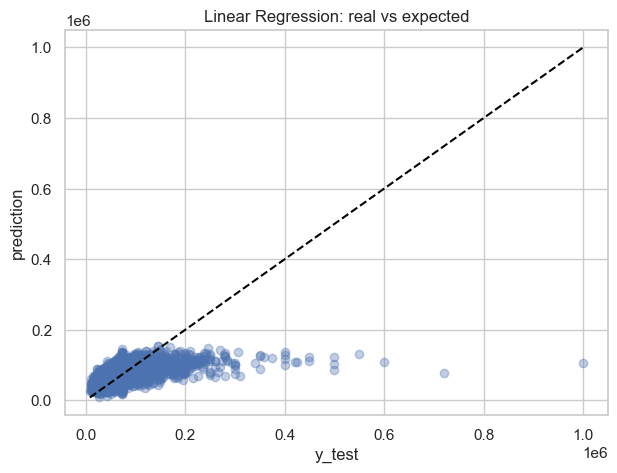

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg, test_pred_reg, alpha=0.35)
lims = [min(y_test_reg.min(), test_pred_reg.min()), max(y_test_reg.max(), test_pred_reg.max())]
ax.plot(lims, lims, color="black", linestyle="--")
ax.set_title("Linear Regression: real vs expected")
ax.set_xlabel("y_test")
ax.set_ylabel("prediction")
plt.show()

##### Cross Validation for regression

In [13]:
cv_reg_fold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_reg_scores = cross_validate(
    clone(reg_model),
    X_reg, y_reg,
    cv=cv_reg_fold,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

reg_cv_summary = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'mean': [
        -cv_reg_scores['test_neg_mean_absolute_error'].mean(),
        -cv_reg_scores['test_neg_root_mean_squared_error'].mean(),
        cv_reg_scores['test_r2'].mean()
    ]
})

reg_cv_summary


,metric,mean
0,MAE,22671.988572
1,RMSE,37277.974321
2,R2,0.254563


### 2.2 Decision Tree Regressor


In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

dt_reg_model = Pipeline([
    ('preprocessor', clone(reg_model.named_steps['preprocessor'])),
    ('regressor', DecisionTreeRegressor(random_state=42)),
])

param_grid = {
    'regressor__max_depth':         [3, 5, 7, 10],
    'regressor__min_samples_leaf':  [10, 25, 50, 100],
    'regressor__min_samples_split': [10, 20, 50],
    'regressor__criterion':         ['squared_error', 'absolute_error'],
    'regressor__splitter':          ['best', 'random'],
}

dt_grid = GridSearchCV(
    dt_reg_model,
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

dt_grid.fit(X_train_reg, y_train_reg)

train_pred_dt_reg = dt_grid.best_estimator_.predict(X_train_reg)
test_pred_dt_reg  = dt_grid.best_estimator_.predict(X_test_reg)

dt_reg_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'MAE': [
        mean_absolute_error(y_train_reg, train_pred_dt_reg),
        mean_absolute_error(y_test_reg, test_pred_dt_reg),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_dt_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_dt_reg)),
    ],
    'R2': [
        r2_score(y_train_reg, train_pred_dt_reg),
        r2_score(y_test_reg, test_pred_dt_reg),
    ],
})

display(dt_reg_metrics)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,split,MAE,RMSE,R2
0,train,21930.801889,36148.304176,0.299185
1,test,22864.564185,37498.950952,0.247531


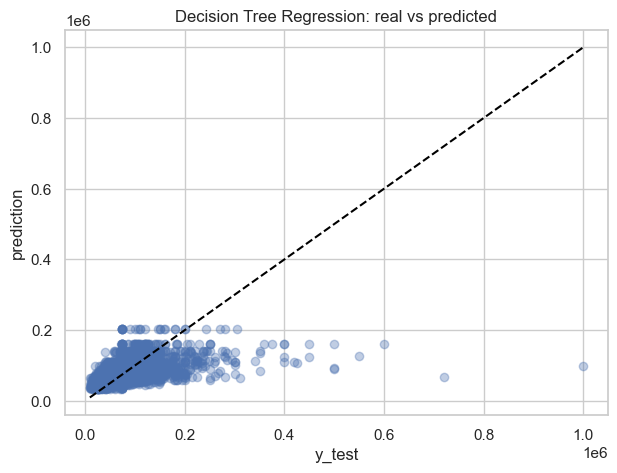

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg, test_pred_dt_reg, alpha=0.35)
lims = [
    min(y_test_reg.min(), test_pred_dt_reg.min()),
    max(y_test_reg.max(), test_pred_dt_reg.max()),
]
ax.plot(lims, lims, color='black', linestyle='--')
ax.set_title('Decision Tree Regression: real vs predicted')
ax.set_xlabel('y_test')
ax.set_ylabel('prediction')
plt.show()

In [18]:
cv_reg_fold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_dt_reg_scores = cross_validate(
    clone(dt_grid.best_estimator_),
    X_reg, y_reg,
    cv=cv_reg_fold,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

dt_reg_cv_summary = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'mean': [
        -cv_dt_reg_scores['test_neg_mean_absolute_error'].mean(),
        -cv_dt_reg_scores['test_neg_root_mean_squared_error'].mean(),
        cv_dt_reg_scores['test_r2'].mean()
    ],
    'std': [
        cv_dt_reg_scores['test_neg_mean_absolute_error'].std(),
        cv_dt_reg_scores['test_neg_root_mean_squared_error'].std(),
        cv_dt_reg_scores['test_r2'].std()
    ]
})

dt_reg_cv_summary

,metric,mean,std
0,MAE,22636.251118,145.431822
1,RMSE,37240.093436,1988.942265
2,R2,0.256120,0.024101


### 2.3 XGBoost

In [20]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb_reg_model = Pipeline([
    ('preprocessor', clone(reg_model.named_steps['preprocessor'])),
    ('regressor', XGBRegressor(random_state=42, n_jobs=-1)),
])

param_grid = {
    'regressor__n_estimators':  [100, 200, 300],
    'regressor__max_depth':     [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample':     [0.7, 0.8, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb_reg_model,
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

xgb_grid.fit(X_train_reg, y_train_reg)

train_pred_xgb_reg = xgb_grid.best_estimator_.predict(X_train_reg)
test_pred_xgb_reg  = xgb_grid.best_estimator_.predict(X_test_reg)

xgb_reg_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'MAE': [
        mean_absolute_error(y_train_reg, train_pred_xgb_reg),
        mean_absolute_error(y_test_reg, test_pred_xgb_reg),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_xgb_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_xgb_reg)),
    ],
    'R2': [
        r2_score(y_train_reg, train_pred_xgb_reg),
        r2_score(y_test_reg, test_pred_xgb_reg),
    ],
})

display(xgb_reg_metrics)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,split,MAE,RMSE,R2
0,train,21606.553845,35216.186362,0.334861
1,test,22011.034696,36525.070522,0.286108


In [21]:
cv_reg_fold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_xgb_reg_scores = cross_validate(
    clone(xgb_grid.best_estimator_),
    X_reg, y_reg,
    cv=cv_reg_fold,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

xgb_reg_cv_summary = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'mean': [
        -cv_xgb_reg_scores['test_neg_mean_absolute_error'].mean(),
        -cv_xgb_reg_scores['test_neg_root_mean_squared_error'].mean(),
        cv_xgb_reg_scores['test_r2'].mean()
    ],
    'std': [
        cv_xgb_reg_scores['test_neg_mean_absolute_error'].std(),
        cv_xgb_reg_scores['test_neg_root_mean_squared_error'].std(),
        cv_xgb_reg_scores['test_r2'].std()
    ]
})

xgb_reg_cv_summary

,metric,mean,std
0,MAE,22018.704063,147.652330
1,RMSE,36462.120976,2055.094927
2,R2,0.286987,0.026220


### 2.4 LGBM

In [46]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import warnings

lgbm_reg_model = Pipeline([
    ('preprocessor', clone(reg_model.named_steps['preprocessor'])),
    ('regressor', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)),
])

param_grid = {
    'regressor__n_estimators':     [100, 200, 300],
    'regressor__max_depth':        [5, 7, 10, -1],
    'regressor__learning_rate':    [0.01, 0.05, 0.1],
    'regressor__subsample':        [0.7, 0.8, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0],
    'regressor__min_gain_to_split': [0.0, 0.01],    
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lgbm_grid = RandomizedSearchCV(
        lgbm_reg_model,
        param_grid,
        n_iter=100,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='r2',
        n_jobs=-1,
        verbose=1,
    )
    lgbm_grid.fit(X_train_reg, y_train_reg)

train_pred_lgbm_reg = lgbm_grid.best_estimator_.predict(X_train_reg)
test_pred_lgbm_reg  = lgbm_grid.best_estimator_.predict(X_test_reg)

lgbm_reg_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'MAE': [
        mean_absolute_error(y_train_reg, train_pred_lgbm_reg),
        mean_absolute_error(y_test_reg, test_pred_lgbm_reg),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_lgbm_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_lgbm_reg)),
    ],
    'R2': [
        r2_score(y_train_reg, train_pred_lgbm_reg),
        r2_score(y_test_reg, test_pred_lgbm_reg),
    ],
})

display(lgbm_reg_metrics)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,MAE,RMSE,R2
0,train,21264.210395,34177.359991,0.373524
1,test,22007.153942,36603.269166,0.283048


In [27]:
cv_reg_fold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_lgbm_reg_scores = cross_validate(
    clone(lgbm_grid.best_estimator_),
    X_reg, y_reg,
    cv=cv_reg_fold,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

lgbm_reg_cv_summary = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'mean': [
        -cv_lgbm_reg_scores['test_neg_mean_absolute_error'].mean(),
        -cv_lgbm_reg_scores['test_neg_root_mean_squared_error'].mean(),
        cv_lgbm_reg_scores['test_r2'].mean()
    ],
    'std': [
        cv_lgbm_reg_scores['test_neg_mean_absolute_error'].std(),
        cv_lgbm_reg_scores['test_neg_root_mean_squared_error'].std(),
        cv_lgbm_reg_scores['test_r2'].std()
    ]
})

lgbm_reg_cv_summary

/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/valid

,metric,mean,std
0,MAE,21968.751152,121.898482
1,RMSE,36478.844540,2072.136018
2,R2,0.286319,0.027460


# 3. Classifications

### 3.1 Logistic regression

Now we will perform binary classification. We will use credit score dataset again and will try to predict purpose of loan

In [29]:
purpose_counts = df['Purpose_Of_Loan'].value_counts()
purpose_prop = purpose_counts / len(df)
purpose_tbl = pd.DataFrame({'count': purpose_counts, 'proportion': purpose_prop})
display(purpose_tbl)

,count,proportion
Purpose_Of_Loan,,
debt_consolidation,19534,0.594425
credit_card,7148,0.217516
home_improvement,1877,0.057118
other,1651,0.050240
major_purchase,704,0.021423
small_business,476,0.014485
car,404,0.012294
medical,336,0.010225
moving,197,0.005995


In [ ]:
X_clf = df.drop(['Purpose_Of_Loan', 'Loan_ID', 'Months_Since_Deliquency'], axis=1).copy()
y_clf = df['Purpose_Of_Loan'].copy()
y_clf = pd.Series(np.where(y_clf == 'debt_consolidation', 1, 0))

display(X_clf.head())
display(y_clf.value_counts(normalize=True))


,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,35000.0,3 years,NaN,160000.0,VERIFIED - income,14.86,1,NaN,6,26,Male,None
1,15000.0,10+ years,Rent,41000.0,not verified,16.51,0,21.0,13,36,Female,None
2,11000.0,5 years,Mortgage,59000.0,not verified,21.75,0,NaN,11,20,Male,None
3,12000.0,NaN,Mortgage,72000.0,VERIFIED - income,15.73,1,NaN,7,20,Female,None
4,20000.0,< 1 year,Other,79404.0,VERIFIED - income,15.32,3,58.0,18,33,Female,None


1    0.594425
0    0.405575
Name: proportion, dtype: float64

In [57]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

numeric_features = X_clf.select_dtypes(include='number').columns.tolist()
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = X_clf.select_dtypes(exclude='number').columns.tolist()
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

clf_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

clf_model = Pipeline([
    ('preprocessor', clf_preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

clf_model.fit(X_train_clf, y_train_clf)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [58]:
train_pred_clf = clf_model.predict(X_train_clf)
test_pred_clf = clf_model.predict(X_test_clf)
train_proba_clf = clf_model.predict_proba(X_train_clf)[:, 1]
test_proba_clf = clf_model.predict_proba(X_test_clf)[:, 1]

clf_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train_clf, train_pred_clf),
        accuracy_score(y_test_clf, test_pred_clf)
    ]
})
clf_metrics['roc_auc'] = [
    roc_auc_score(y_train_clf, train_proba_clf),
    roc_auc_score(y_test_clf, test_proba_clf)
]
clf_metrics

,split,accuracy,roc_auc
0,train,0.610560,0.596125
1,test,0.610072,0.591296


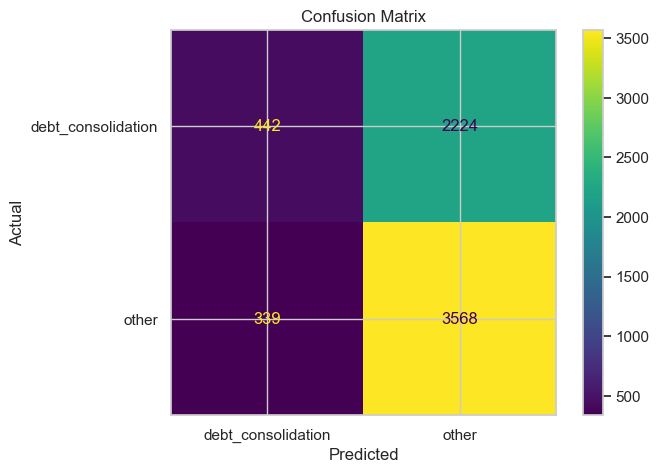

In [59]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test_clf, test_pred_clf), display_labels=['debt_consolidation', 'other']).plot(ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

In [60]:
all_features = clf_model.named_steps['preprocessor']\
    .get_feature_names_out()

coef_clf = pd.Series(
    clf_model.named_steps['classifier'].coef_[0],
    index=all_features
).sort_values(key=np.abs, ascending=False)

coef_clf.head(10)

num__Loan_Amount_Requested                       0.265715
cat__Home_Owner_Rent                             0.180488
num__Debt_To_Income                              0.156714
cat__Home_Owner_Own                             -0.133746
num__Annual_Income                              -0.107100
cat__Length_Employed_1 year                      0.099962
cat__Interest_Rate_None                          0.099246
cat__Income_Verified_VERIFIED - income source    0.086342
cat__Length_Employed_7 years                     0.080080
cat__Length_Employed_5 years                    -0.071283
dtype: float64

##### Cross Validation for classification

In [61]:
cv_clf_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_clf_scores = cross_validate(
    clone(clf_model),
    X_clf, y_clf,
    cv=cv_clf_fold,
    scoring=[
        'accuracy',
        'f1',
        'precision',
        'recall',
        'roc_auc'
    ]
)

clf_cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
    'mean': [
        cv_clf_scores['test_accuracy'].mean(),
        cv_clf_scores['test_f1'].mean(),
        cv_clf_scores['test_precision'].mean(),
        cv_clf_scores['test_recall'].mean(),
        cv_clf_scores['test_roc_auc'].mean()
    ]
})

clf_cv_summary

,metric,mean
0,accuracy,0.609610
1,f1,0.735526
2,precision,0.615687
3,recall,0.913331
4,roc_auc,0.592486


### 3.2 Decision Tree Classifier

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_clf_model = Pipeline([
    ('preprocessor', clone(clf_model.named_steps['preprocessor'])),
    ('classifier', DecisionTreeClassifier(random_state=42)),
])

param_grid = {
    'classifier__max_depth':         [3, 5, 7, 10],
    'classifier__min_samples_leaf':  [10, 25, 50, 100],
    'classifier__min_samples_split': [10, 20, 50],
    'classifier__criterion':         ['gini', 'entropy'],
    'classifier__splitter':          ['best', 'random'],
}

dt_clf_grid = GridSearchCV(
    dt_clf_model,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

dt_clf_grid.fit(X_train_clf, y_train_clf)

train_pred_dt_clf = dt_clf_grid.best_estimator_.predict(X_train_clf)
test_pred_dt_clf  = dt_clf_grid.best_estimator_.predict(X_test_clf)
train_proba_dt_clf = dt_clf_grid.best_estimator_.predict_proba(X_train_clf)[:, 1]
test_proba_dt_clf  = dt_clf_grid.best_estimator_.predict_proba(X_test_clf)[:, 1]

dt_clf_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train_clf, train_pred_dt_clf),
        accuracy_score(y_test_clf, test_pred_dt_clf)
    ],
    'roc_auc': [
        roc_auc_score(y_train_clf, train_proba_dt_clf),
        roc_auc_score(y_test_clf, test_proba_dt_clf)
    ]
})

display(dt_clf_metrics)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,split,accuracy,roc_auc
0,train,0.624215,0.605478
1,test,0.614788,0.594821


Text(0, 0.5, 'True')

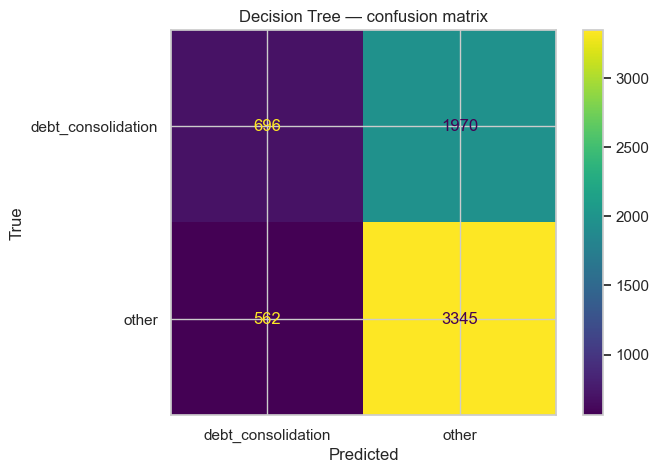

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_clf, test_pred_dt_clf),
    display_labels=['debt_consolidation', 'other'],
).plot(ax=ax)
ax.set_title('Decision Tree — confusion matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

In [40]:
cv_clf_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_dt_clf_scores = cross_validate(
    clone(dt_clf_grid.best_estimator_),
    X_clf, y_clf,
    cv=cv_clf_fold,
    scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
)

dt_clf_cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
    'mean': [
        cv_dt_clf_scores['test_accuracy'].mean(),
        cv_dt_clf_scores['test_f1'].mean(),
        cv_dt_clf_scores['test_precision'].mean(),
        cv_dt_clf_scores['test_recall'].mean(),
        cv_dt_clf_scores['test_roc_auc'].mean()
    ],
    'std': [
        cv_dt_clf_scores['test_accuracy'].std(),
        cv_dt_clf_scores['test_f1'].std(),
        cv_dt_clf_scores['test_precision'].std(),
        cv_dt_clf_scores['test_recall'].std(),
        cv_dt_clf_scores['test_roc_auc'].std()
    ]
})

dt_clf_cv_summary

,metric,mean,std
0,accuracy,0.616305,0.003086
1,f1,0.733529,0.006164
2,precision,0.624613,0.002930
3,recall,0.888914,0.023086
4,roc_auc,0.593655,0.007378


### 3.3 XGBoost Classifier

In [42]:
from xgboost import XGBClassifier

xgb_clf_model = Pipeline([
    ('preprocessor', clone(clf_model.named_steps['preprocessor'])),
    ('classifier', XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')),
])

param_grid = {
    'classifier__n_estimators':     [100, 200, 300],
    'classifier__max_depth':        [3, 5, 7],
    'classifier__learning_rate':    [0.01, 0.05, 0.1],
    'classifier__subsample':        [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_clf_grid = GridSearchCV(
    xgb_clf_model,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

xgb_clf_grid.fit(X_train_clf, y_train_clf)

train_pred_xgb_clf  = xgb_clf_grid.best_estimator_.predict(X_train_clf)
test_pred_xgb_clf   = xgb_clf_grid.best_estimator_.predict(X_test_clf)
train_proba_xgb_clf = xgb_clf_grid.best_estimator_.predict_proba(X_train_clf)[:, 1]
test_proba_xgb_clf  = xgb_clf_grid.best_estimator_.predict_proba(X_test_clf)[:, 1]

xgb_clf_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train_clf, train_pred_xgb_clf),
        accuracy_score(y_test_clf, test_pred_xgb_clf)
    ],
    'roc_auc': [
        roc_auc_score(y_train_clf, train_proba_xgb_clf),
        roc_auc_score(y_test_clf, test_proba_xgb_clf)
    ]
})

display(xgb_clf_metrics)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,split,accuracy,roc_auc
0,train,0.631861,0.632253
1,test,0.620569,0.607526


In [43]:
cv_clf_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_xgb_clf_scores = cross_validate(
    clone(xgb_clf_grid.best_estimator_),
    X_clf, y_clf,
    cv=cv_clf_fold,
    scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
)

xgb_clf_cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
    'mean': [
        cv_xgb_clf_scores['test_accuracy'].mean(),
        cv_xgb_clf_scores['test_f1'].mean(),
        cv_xgb_clf_scores['test_precision'].mean(),
        cv_xgb_clf_scores['test_recall'].mean(),
        cv_xgb_clf_scores['test_roc_auc'].mean()
    ],
    'std': [
        cv_xgb_clf_scores['test_accuracy'].std(),
        cv_xgb_clf_scores['test_f1'].std(),
        cv_xgb_clf_scores['test_precision'].std(),
        cv_xgb_clf_scores['test_recall'].std(),
        cv_xgb_clf_scores['test_roc_auc'].std()
    ]
})

xgb_clf_cv_summary

,metric,mean,std
0,accuracy,0.620687,0.002564
1,f1,0.738253,0.002983
2,precision,0.625821,0.000757
3,recall,0.899970,0.008148
4,roc_auc,0.605720,0.006373


### 3.4 LGBM Classifier

In [47]:
from lightgbm import LGBMClassifier

lgbm_clf_model = Pipeline([
    ('preprocessor', clone(clf_model.named_steps['preprocessor'])),
    ('classifier', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
])

param_grid = {
    'classifier__n_estimators':     [100, 200, 300],
    'classifier__max_depth':        [5, 7, 10, -1],
    'classifier__learning_rate':    [0.01, 0.05, 0.1],
    'classifier__subsample':        [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
}

lgbm_clf_grid = RandomizedSearchCV(
    lgbm_clf_model,
    param_grid,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lgbm_clf_grid.fit(X_train_clf, y_train_clf)

train_pred_lgbm_clf  = lgbm_clf_grid.best_estimator_.predict(X_train_clf)
test_pred_lgbm_clf   = lgbm_clf_grid.best_estimator_.predict(X_test_clf)
train_proba_lgbm_clf = lgbm_clf_grid.best_estimator_.predict_proba(X_train_clf)[:, 1]
test_proba_lgbm_clf  = lgbm_clf_grid.best_estimator_.predict_proba(X_test_clf)[:, 1]

lgbm_clf_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train_clf, train_pred_lgbm_clf),
        accuracy_score(y_test_clf, test_pred_lgbm_clf)
    ],
    'roc_auc': [
        roc_auc_score(y_train_clf, train_proba_lgbm_clf),
        roc_auc_score(y_test_clf, test_proba_lgbm_clf)
    ]
})

display(lgbm_clf_metrics)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,split,accuracy,roc_auc
0,train,0.634752,0.632639
1,test,0.618287,0.607903


In [ ]:
cv_clf_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_lgbm_clf_scores = cross_validate(
    clone(lgbm_clf_grid.best_estimator_),
    X_clf, y_clf,
    cv=cv_clf_fold,
    scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
)

lgbm_clf_cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
    'mean': [
        cv_lgbm_clf_scores['test_accuracy'].mean(),
        cv_lgbm_clf_scores['test_f1'].mean(),
        cv_lgbm_clf_scores['test_precision'].mean(),
        cv_lgbm_clf_scores['test_recall'].mean(),
        cv_lgbm_clf_scores['test_roc_auc'].mean()
    ],
    'std': [
        cv_lgbm_clf_scores['test_accuracy'].std(),
        cv_lgbm_clf_scores['test_f1'].std(),
        cv_lgbm_clf_scores['test_precision'].std(),
        cv_lgbm_clf_scores['test_recall'].std(),
        cv_lgbm_clf_scores['test_roc_auc'].std()
    ]
})

lgbm_clf_cv_summary

/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/v

,metric,mean,std
0,accuracy,0.620017,0.002223
1,f1,0.741452,0.001498
2,precision,0.622511,0.001824
3,recall,0.916607,0.005037
4,roc_auc,0.604842,0.006015


### 3.5 Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_clf_model = Pipeline([
    ('preprocessor', clone(clf_model.named_steps['preprocessor'])),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_grid = {
    'classifier__n_estimators':    [100, 200, 300],
    'classifier__max_depth':       [3, 5, 7, None],
    'classifier__min_samples_leaf':[10, 25, 50],
    'classifier__max_features':    ['sqrt', 'log2'],
    'classifier__class_weight':    ['balanced', None],
}

rf_clf_grid = GridSearchCV(
    rf_clf_model,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1,
    verbose=1,
)

rf_clf_grid.fit(X_train_clf, y_train_clf)

train_pred_rf_clf  = rf_clf_grid.best_estimator_.predict(X_train_clf)
test_pred_rf_clf   = rf_clf_grid.best_estimator_.predict(X_test_clf)
train_proba_rf_clf = rf_clf_grid.best_estimator_.predict_proba(X_train_clf)
test_proba_rf_clf  = rf_clf_grid.best_estimator_.predict_proba(X_test_clf)

rf_clf_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train_clf, train_pred_rf_clf),
        accuracy_score(y_test_clf, test_pred_rf_clf)
    ],
    'roc_auc': [
        roc_auc_score(y_train_clf, train_pred_rf_clf),
        roc_auc_score(y_test_clf, test_pred_rf_clf)
    ]
})

display(rf_clf_metrics)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

,split,accuracy,roc_auc
0,train,0.640496,0.626968
1,test,0.595466,0.578994


In [74]:
cv_clf_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf_clf_scores = cross_validate(
    clone(rf_clf_grid.best_estimator_),
    X_clf, y_clf,
    cv=cv_clf_fold,
    scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
)

rf_clf_cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
    'mean': [
        cv_rf_clf_scores['test_accuracy'].mean(),
        cv_rf_clf_scores['test_f1'].mean(),
        cv_rf_clf_scores['test_precision'].mean(),
        cv_rf_clf_scores['test_recall'].mean(),
        cv_rf_clf_scores['test_roc_auc'].mean()
    ],
    'std': [
        cv_rf_clf_scores['test_accuracy'].std(),
        cv_rf_clf_scores['test_f1'].std(),
        cv_rf_clf_scores['test_precision'].std(),
        cv_rf_clf_scores['test_recall'].std(),
        cv_rf_clf_scores['test_roc_auc'].std()
    ]
})

rf_clf_cv_summary

,metric,mean,std
0,accuracy,0.592660,0.006284
1,f1,0.656778,0.007754
2,precision,0.657846,0.004146
3,recall,0.655831,0.013455
4,roc_auc,0.607459,0.005504


### 3.6 Extra Trees Classifier

In [75]:
from sklearn.ensemble import ExtraTreesClassifier

et_clf_model = Pipeline([
    ('preprocessor', clone(clf_model.named_steps['preprocessor'])),
    ('classifier', ExtraTreesClassifier(random_state=42, n_jobs=-1)),
])

param_grid = {
    'classifier__n_estimators':    [100, 200, 300],
    'classifier__max_depth':       [3, 5, 7, None],
    'classifier__min_samples_leaf':[10, 25, 50],
    'classifier__max_features':    ['sqrt', 'log2'],
    'classifier__class_weight':    ['balanced', None],
}

et_clf_grid = GridSearchCV(
    et_clf_model,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1,
    verbose=1,
)

et_clf_grid.fit(X_train_clf, y_train_clf)

train_pred_et_clf  = et_clf_grid.best_estimator_.predict(X_train_clf)
test_pred_et_clf   = et_clf_grid.best_estimator_.predict(X_test_clf)
train_proba_et_clf = et_clf_grid.best_estimator_.predict_proba(X_train_clf)
test_proba_et_clf  = et_clf_grid.best_estimator_.predict_proba(X_test_clf)

et_clf_metrics = pd.DataFrame({
    'split': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train_clf, train_pred_et_clf),
        accuracy_score(y_test_clf, test_pred_et_clf)
    ],
    'roc_auc': [
        roc_auc_score(y_train_clf, train_pred_et_clf),
        roc_auc_score(y_test_clf, test_pred_et_clf)
    ]
})

display(et_clf_metrics)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/rafalzalecki/studia/coding/sad_lab/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

,split,accuracy,roc_auc
0,train,0.616570,0.532895
1,test,0.607485,0.523516


In [76]:
cv_clf_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_et_clf_scores = cross_validate(
    clone(et_clf_grid.best_estimator_),
    X_clf, y_clf,
    cv=cv_clf_fold,
    scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
)

et_clf_cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
    'mean': [
        cv_et_clf_scores['test_accuracy'].mean(),
        cv_et_clf_scores['test_f1'].mean(),
        cv_et_clf_scores['test_precision'].mean(),
        cv_et_clf_scores['test_recall'].mean(),
        cv_et_clf_scores['test_roc_auc'].mean()
    ],
    'std': [
        cv_et_clf_scores['test_accuracy'].std(),
        cv_et_clf_scores['test_f1'].std(),
        cv_et_clf_scores['test_precision'].std(),
        cv_et_clf_scores['test_recall'].std(),
        cv_et_clf_scores['test_roc_auc'].std()
    ]
})

et_clf_cv_summary

,metric,mean,std
0,accuracy,0.607145,0.002068
1,f1,0.745100,0.001551
2,precision,0.606452,0.001350
3,recall,0.965957,0.005096
4,roc_auc,0.598844,0.006838
